In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    print("Colab detected: upgrading transformers for compatibility...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "-q", "transformers>=4.30.0"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from transformers import AutoTokenizer, DistilBertForSequenceClassification

try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import ClassificationMetric
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "aif360==0.6.1"])
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import ClassificationMetric

sns.set_theme(style="whitegrid")
PROJECT_DIR = Path.cwd()
SEED = 42
THRESHOLD = 0.4  
MODEL_DIR = PROJECT_DIR / "saved_model/part1_baseline"
DATA_PATH = PROJECT_DIR / "jigsaw-unintended-bias-train.csv"

print("Running in Colab:", IN_COLAB)
print("Project directory:", PROJECT_DIR.resolve())
print("Data path:", DATA_PATH)
print("Model path:", MODEL_DIR)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Colab detected: upgrading transformers for compatibility...
Running in Colab: True
Project directory: /content
Data path: /content/jigsaw-unintended-bias-train.csv
Model path: /content/saved_model/part1_baseline
Device: cuda


/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

In [ ]:
assert DATA_PATH.exists(), f"Missing dataset file: {DATA_PATH}"

usecols = ["comment_text", "toxic", "black", "white"]
df = pd.read_csv(DATA_PATH, usecols=usecols, encoding="utf-8", low_memory=False)

df = df.dropna(subset=["comment_text", "toxic", "black", "white"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

print("Loaded rows after cleaning:", len(df))
print(df[["toxic", "black", "white", "label"]].describe())

Loaded rows after cleaning: 426705
               toxic          black          white          label
count  426705.000000  426705.000000  426705.000000  426705.000000
mean        0.140177       0.034306       0.056629       0.113507
std         0.218470       0.167674       0.215385       0.317212
min         0.000000       0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000       0.000000
50%         0.000000       0.000000       0.000000       0.000000
75%         0.200000       0.000000       0.000000       0.000000
max         1.000000       1.000000       1.000000       1.000000


In [6]:
TARGET_TOTAL = 120_000
TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000

subset_df, _ = train_test_split(
    df,
    train_size=TARGET_TOTAL,
    stratify=df["label"],
    random_state=SEED,
)

_, eval_df = train_test_split(
    subset_df,
    train_size=TRAIN_SIZE,
    stratify=subset_df["label"],
    random_state=SEED,
)

assert len(eval_df) == EVAL_SIZE
print("Evaluation subset shape:", eval_df.shape)
print(eval_df["label"].value_counts(normalize=True).rename("ratio"))

Evaluation subset shape: (20000, 5)
label
0    0.8865
1    0.1135
Name: ratio, dtype: float64


In [7]:
high_black_df = eval_df[eval_df["black"] >= 0.5].copy()
reference_df = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print("High-black cohort size:", len(high_black_df))
print("Reference cohort size:", len(reference_df))

if len(high_black_df) < 50 or len(reference_df) < 50:
    print("Warning: very small cohort size; metrics may be unstable.")

High-black cohort size: 749
Reference cohort size: 872


In [8]:
assert MODEL_DIR.exists(), f"Missing Part 1 model checkpoint: {MODEL_DIR}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model = DistilBertForSequenceClassification.from_pretrained(str(MODEL_DIR)).to(device)
model.eval()

def predict_probabilities(texts, batch_size=64, max_len=128):
    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            enc = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=max_len,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.extend(probs)
    return np.array(probs_all)

for cohort_name, cohort_df in [("high_black", high_black_df), ("reference", reference_df)]:
    probs = predict_probabilities(cohort_df["comment_text"].tolist())
    cohort_df["y_prob"] = probs
    cohort_df["y_pred"] = (probs >= THRESHOLD).astype(int)
    print(f"{cohort_name}: mean prob={probs.mean():.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

high_black: mean prob=0.3366
reference: mean prob=0.2544


In [9]:
def safe_div(n, d):
    return float(n) / float(d) if d else np.nan

def cohort_metrics(df_cohort):
    y_true = df_cohort["label"].values
    y_pred = df_cohort["y_pred"].values
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "TPR": safe_div(tp, tp + fn),
        "FPR": safe_div(fp, fp + tn),
        "FNR": safe_div(fn, fn + tp),
        "Precision": safe_div(tp, tp + fp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "N": int(len(df_cohort)),
        "CM": cm,
    }

hb_m = cohort_metrics(high_black_df)
ref_m = cohort_metrics(reference_df)

disparate_impact_ratio = safe_div(hb_m["FPR"], ref_m["FPR"])

summary_df = pd.DataFrame([
    {"cohort": "high_black", **{k: v for k, v in hb_m.items() if k != "CM"}},
    {"cohort": "reference", **{k: v for k, v in ref_m.items() if k != "CM"}},
])

display(summary_df[["cohort", "N", "TPR", "FPR", "FNR", "Precision", "TN", "FP", "FN", "TP"]])
print(f"Disparate Impact ratio (FPR high_black / FPR reference): {disparate_impact_ratio:.4f}")

,cohort,N,TPR,FPR,FNR,Precision,TN,FP,FN,TP
0,high_black,749,0.688000,0.166333,0.312000,0.674510,416,83,78,172
1,reference,872,0.495902,0.108280,0.504098,0.640212,560,68,123,121


Disparate Impact ratio (FPR high_black / FPR reference): 1.5361


In [10]:
audit_df = pd.concat([
    high_black_df.assign(group=0),
    reference_df.assign(group=1),
], ignore_index=True)

true_df = audit_df[["label", "group"]].copy()
pred_df = audit_df[["y_pred", "group"]].rename(columns={"y_pred": "label"}).copy()

bld_true = BinaryLabelDataset(
    df=true_df,
    label_names=["label"],
    protected_attribute_names=["group"],
)
bld_pred = BinaryLabelDataset(
    df=pred_df,
    label_names=["label"],
    protected_attribute_names=["group"],
)

metric = ClassificationMetric(
    bld_true,
    bld_pred,
    unprivileged_groups=[{"group": 0}],
    privileged_groups=[{"group": 1}],
)

statistical_parity_difference = metric.statistical_parity_difference()
equal_opportunity_difference = metric.equal_opportunity_difference()

print(f"Statistical Parity Difference: {statistical_parity_difference:.4f}")
print(f"Equal Opportunity Difference: {equal_opportunity_difference:.4f}")

Statistical Parity Difference: 0.1237
Equal Opportunity Difference: 0.1921


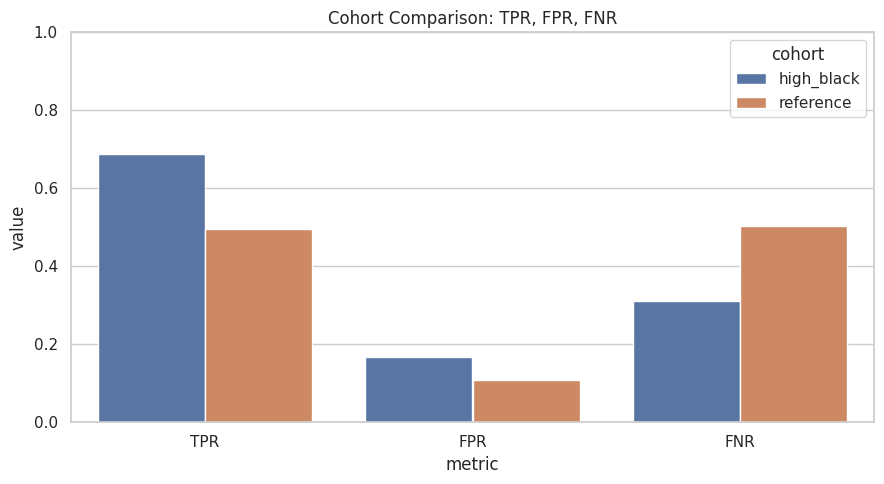

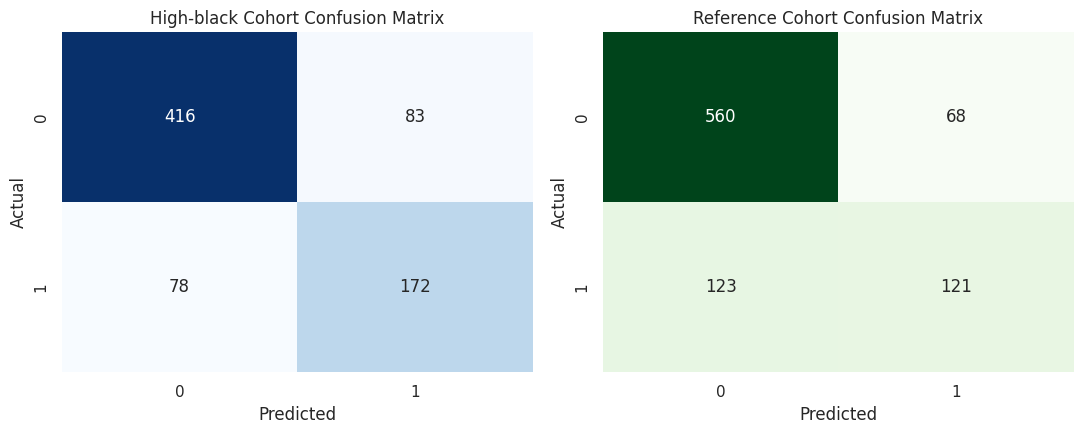

In [11]:
# Grouped bar chart for TPR, FPR, FNR
plot_df = pd.DataFrame([
    {"cohort": "high_black", "TPR": hb_m["TPR"], "FPR": hb_m["FPR"], "FNR": hb_m["FNR"]},
    {"cohort": "reference", "TPR": ref_m["TPR"], "FPR": ref_m["FPR"], "FNR": ref_m["FNR"]},
])
long_plot = plot_df.melt(id_vars="cohort", value_vars=["TPR", "FPR", "FNR"], var_name="metric", value_name="value")

plt.figure(figsize=(9, 5))
sns.barplot(data=long_plot, x="metric", y="value", hue="cohort")
plt.title("Cohort Comparison: TPR, FPR, FNR")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Two confusion matrices (one per cohort)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(hb_m["CM"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("High-black Cohort Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(ref_m["CM"], annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Reference Cohort Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [12]:
final_table = summary_df[["cohort", "N", "TPR", "FPR", "FNR", "Precision"]].copy()
final_table.loc[final_table.index[0], "DisparateImpact_FPR_ratio"] = disparate_impact_ratio
final_table.loc[final_table.index[0], "StatisticalParityDifference"] = statistical_parity_difference
final_table.loc[final_table.index[0], "EqualOpportunityDifference"] = equal_opportunity_difference
display(final_table)

,cohort,N,TPR,FPR,FNR,Precision,DisparateImpact_FPR_ratio,StatisticalParityDifference,EqualOpportunityDifference
0,high_black,749,0.688000,0.166333,0.312000,0.674510,1.536131,0.123711,0.192098
1,reference,872,0.495902,0.108280,0.504098,0.640212,NaN,NaN,NaN


## Discussion Questions

### Which metric shows the largest disparity?
The largest disparity appears in the **TPR/FNR pair** (same gap, opposite direction):

- High-black TPR = 172/250 = **0.688**
- Reference TPR = 121/244 = **0.496**
- TPR gap = **0.192**

Equivalent FNR view:

- High-black FNR = 78/250 = **0.312**
- Reference FNR = 123/244 = **0.504**
- FNR gap = **0.192**

The FPR disparity is smaller:

- High-black FPR = 83/499 = **0.166**
- Reference FPR = 68/628 = **0.108**
- FPR gap = **0.058**
- FPR ratio (Disparate Impact) = **~1.54**

### Does the model predominantly over-flag, under-flag, or both?
The model **predominantly over-flags the high-black cohort** (higher FPR). It does **not** under-flag this cohort, since its FNR is lower and TPR is higher than the reference cohort.

So the observed pattern is:

- **High-black cohort:** more false positives, but also more true toxic detections.
- **Reference cohort:** fewer false positives, but more toxic comments missed.

### Real-world consequences
- **Higher FPR on high-black cohort:** more non-toxic comments are incorrectly flagged/blocked, which can create unequal user burden, reduced trust, and perceived discriminatory moderation.
- **Higher FNR on reference cohort:** more genuinely toxic comments remain visible, increasing exposure to harmful content and reducing safety.
- **Platform-level implication:** moderation errors are distributed unevenly across cohorts, meaning average accuracy alone hides meaningful fairness harms.